# House Price Prediction - Exploratory Data Analysis (EDA)

**IBM SkillsBuild Data Analytics with AI Internship 2026**

**Dataset:** Kaggle *House Prices - Advanced Regression Techniques* (Ames, Iowa)\
**Task:** predict the sale price of a house (`SalePrice`) from 79 property features.

## What this notebook does

This notebook explores the data to understand it **before** building any model:

1. Loads the 4 raw files from `data/` (relative paths, files are never modified).
2. Checks shapes, data types, duplicates, and missing values.
3. Studies the target `SalePrice` (raw and `log1p` transformed).
4. Explains what the missing values actually mean (many *mean "this feature is absent"*).
5. Looks at correlations between numeric features and `SalePrice`.
6. Plots key numeric and categorical features.

Everything shown below is computed live from the CSV files. No model is trained and
no result is invented - the numbers are just whatever the data says.

> Reading guide for beginners: a **cell** is a block of code or text.
> Press *Shift+Enter* on a code cell to run it. The output appears right below it.

## 1. Setup: libraries and display options

We import the standard data-science libraries and make printed tables readable.
No warnings are suppressed; we only keep the notebook tidy.

In [ ]:
# Standard data + plotting libraries
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Keep printed tables readable inside the notebook
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 90

print(f"pandas {pd.__version__} | numpy {np.__version__} | "
      f"matplotlib {matplotlib.__version__} | seaborn {sns.__version__}")

pandas 3.0.6 | numpy 2.5.0 | matplotlib 3.11.2 | seaborn 0.13.2


## 2. Load the 4 raw files (relative paths)

All paths are **relative** to the notebook location, so the notebook runs anywhere
as long as the `data/` folder sits next to it. We **only read** the files - nothing
is written back into `data/`.

In [ ]:
DATA_DIR = "data"

train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
sample_submission = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

with open(os.path.join(DATA_DIR, "data_description.txt"), "r", encoding="utf-8") as f:
    data_description = f.read()

print(f"train.csv             -> {train.shape[0]} rows x {train.shape[1]} columns")
print(f"test.csv              -> {test.shape[0]} rows x {test.shape[1]} columns")
print(f"sample_submission.csv -> {sample_submission.shape[0]} rows x {sample_submission.shape[1]} columns")
print(f"data_description.txt  -> {len(data_description.splitlines())} lines")

print("\ntrain columns:", list(train.columns))
print("\ntest columns:", list(test.columns))

train.csv             -> 1460 rows x 81 columns
test.csv              -> 1459 rows x 80 columns
sample_submission.csv -> 1459 rows x 2 columns
data_description.txt  -> 523 lines

train columns: ['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', '

## 3. Shape, data types, duplicates

- **train.csv** has the *answer key* (`SalePrice`) and is what we learn from.
- **test.csv** has the *same 80 features but no price* - we predict its price later.
- **sample_submission.csv** only shows the required `Id, SalePrice` output format.

First a quick sanity check: do the files have the expected number of rows, are the
data types sensible, and are there any duplicate rows?

In [ ]:
print("=== train.csv ===")
print("shape:", train.shape)
print("columns:", len(train.columns))

print("\n=== test.csv ===")
print("shape:", test.shape)
print("columns:", len(test.columns))

print("\n=== Duplicate rows (rows that repeat entirely) ===")
print(f"train: {train.duplicated().sum()}")
print(f"test : {test.duplicated().sum()}")

print("\n=== Duplicate Ids in train ===")
print(int(train["Id"].duplicated().sum()))

=== train.csv ===
shape: (1460, 81)
columns: 81

=== test.csv ===
shape: (1459, 80)
columns: 80

=== Duplicate rows (rows that repeat entirely) ===
train: 0
test : 0

=== Duplicate Ids in train ===
0


### Data types

Column types fall into two groups: **numeric** (areas, year built, ratings as
numbers) and **text/categorical** (neighbourhood, zoning, quality letters such as
`TA`/`Ex`). pandas 3.0 labels text columns as `str`.

In [ ]:
print("=== Column counts by data type in train ===")
print(train.dtypes.value_counts())

num_cols = [c for c in train.columns if pd.api.types.is_numeric_dtype(train[c])]
cat_cols = [c for c in train.columns if c not in num_cols]

print(f"\nNumeric columns ({len(num_cols)}):")
print(num_cols)
print(f"\nText/categorical columns ({len(cat_cols)}):")
print(cat_cols)

=== Column counts by data type in train ===
str        43
int64      35
float64     3
Name: count, dtype: int64

Numeric columns (38):
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Text/categorical columns (43):
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposur

## 4. The target variable: SalePrice

`SalePrice` is the house price in US dollars and is our prediction target.
We look at its statistics and its **distribution** (a histogram). The shape of the
distribution matters: predictions on Kaggle are scored with **RMSLE** (Root Mean
Squared Logarithmic Error), and RMSLE behaves best when the *log* of the price is
roughly symmetric, so many projects model `log1p(SalePrice)` instead of the raw
price.

> `log1p(x)` = `log(1 + x)`. Adding 1 avoids `log(0)` and is a common safe trick.

In [ ]:
price = train["SalePrice"]
print("=== SalePrice statistics ===")
print(price.describe().round(2))
print(f"\nMissing values in SalePrice: {price.isna().sum()}")

print("\n=== Skewness (a measure of asymmetry) ===")
print(f"raw SalePrice    : {price.skew():.3f}   (positive => long tail on the right)")
print(f"log1p(SalePrice) : {price.transform('log1p').skew():.3f}   (closer to 0 => more symmetric)")

=== SalePrice statistics ===
count      1460.0
mean     180921.2
std       79442.5
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64

Missing values in SalePrice: 0

=== Skewness (a measure of asymmetry) ===
raw SalePrice    : 1.883   (positive => long tail on the right)
log1p(SalePrice) : 0.121   (closer to 0 => more symmetric)


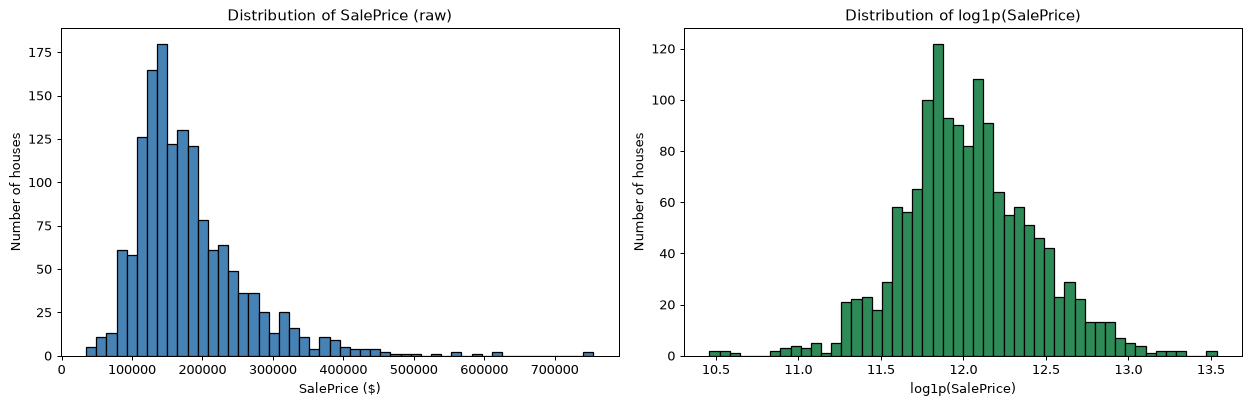

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

axes[0].hist(price, bins=50, edgecolor="black", color="steelblue")
axes[0].set_title("Distribution of SalePrice (raw)")
axes[0].set_xlabel("SalePrice ($)")
axes[0].set_ylabel("Number of houses")

axes[1].hist(np.log1p(price), bins=50, edgecolor="black", color="seagreen")
axes[1].set_title("Distribution of log1p(SalePrice)")
axes[1].set_xlabel("log1p(SalePrice)")
axes[1].set_ylabel("Number of houses")

plt.tight_layout()
plt.show()

## 5. Missing values: what they really mean

Some columns have empty (missing) values. To handle them later we first have to
understand *why* they are missing.

**Crucial point:** in this dataset many missing values do **not** mean "the data
was lost". They mean **"this feature does not exist for this house"**. The official
`data_description.txt` uses the label `NA` exactly for that:

| Column | `NA` means |
|---|---|
| `Alley` | No alley access |
| `PoolQC` | No pool |
| `Fence` | No fence |
| `FireplaceQu` | No fireplace |
| `BsmtQual` ... `BsmtFinType2` | No basement |
| `GarageType` ... `GarageCond` | No garage |
| `MasVnrType` | No masonry veneer |

So a missing `PoolQC` is *information* ("there is no pool"), not an error.
The proper fix later is to turn these into a new category like `"No_Pool"`
**before** encoding, instead of deleting rows.

Below: how many values are missing per column, with percentages.

In [ ]:
missing_info = (
    train.isna()
    .sum()
    .to_frame("missing_count")
    .assign(percentage=lambda d: (d["missing_count"] / len(train) * 100).round(2))
    .query("missing_count > 0")
    .sort_values("percentage", ascending=False)
)
print(f"{missing_info.shape[0]} of {train.shape[1]} columns contain missing values\n")
missing_info

19 of 81 columns contain missing values



,missing_count,percentage
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


### Check: are the "absent feature" columns really missing (NaN)?

Let's verify that the columns named above are stored as empty cells (`NaN`) and do
*not* contain a literal text `"NA"` as a real value. This confirms the description
above applies to this exact CSV.

In [ ]:
absent_like_cols = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu", "MasVnrType",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
]

absent_meaning = {
    "PoolQC": "No pool", "MiscFeature": "No misc feature", "Alley": "No alley",
    "Fence": "No fence", "FireplaceQu": "No fireplace", "MasVnrType": "No masonry veneer",
    "BsmtQual": "No basement", "BsmtCond": "No basement", "BsmtExposure": "No basement",
    "BsmtFinType1": "No basement", "BsmtFinType2": "No basement",
    "GarageType": "No garage", "GarageFinish": "No garage",
    "GarageQual": "No garage", "GarageCond": "No garage",
}

rows = []
for c in absent_like_cols:
    rows.append({
        "column": c,
        "NaN count": int(train[c].isna().sum()),
        "text 'NA' count": int((train[c] == "NA").sum()),
        "distinct real values": int(train[c].nunique(dropna=True)),
        "meaning of NaN (data_description.txt)": absent_meaning[c],
    })

pd.DataFrame(rows)

,column,NaN count,text 'NA' count,distinct real values,meaning of NaN (data_description.txt)
0,PoolQC,1453,0,3,No pool
1,MiscFeature,1406,0,4,No misc feature
2,Alley,1369,0,2,No alley
3,Fence,1179,0,4,No fence
4,FireplaceQu,690,0,5,No fireplace
5,MasVnrType,872,0,3,No masonry veneer
6,BsmtQual,37,0,4,No basement
7,BsmtCond,37,0,4,No basement
8,BsmtExposure,38,0,4,No basement
9,BsmtFinType1,37,0,6,No basement


### Genuinely missing values (need careful handling)

Three columns are different: their missing values are **not** explained by
`data_description.txt` as a `NA` category, so they look like real gaps:

- `LotFrontage` (numeric, 259 missing = 17.7%) - street-front footage was simply
  not recorded for some houses.
- `MasVnrArea` (numeric, 8 missing) - masonry area missing while `MasVnrType`
  exists; likely should be filled with `0` where type is "None".
- `Electrical` (1 missing) - a single house with an unknown electrical system.

These need imputation strategies of their own during preprocessing
(for example median/neighbourhood-based filling for `LotFrontage`).

## 6. Which numeric features relate to SalePrice?

**Pearson correlation** measures how linearly two numeric variables move together:
+1 = perfect positive line, -1 = perfect negative line, 0 = no linear relation.

`Id` is just a row number and has no real meaning, so we drop it here.

First the ranking: which numeric features correlate most strongly with price?

In [ ]:
numeric = train[["SalePrice"] + [c for c in num_cols if c not in ("Id", "SalePrice")]]

corr_with_price = numeric.corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False)

print("=== Top 20 numeric correlations with SalePrice ===\n")
corr_with_price.head(20).to_frame("correlation with SalePrice")

=== Top 20 numeric correlations with SalePrice ===



,correlation with SalePrice
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101


The top features tell a sensible story: overall quality (`OverallQual`),
finished living area (`GrLivArea`), garage capacity/area, basement size and
`YearBuilt` all move together with price.

Now a readable heatmap of `SalePrice` plus the 12 most correlated numeric features.

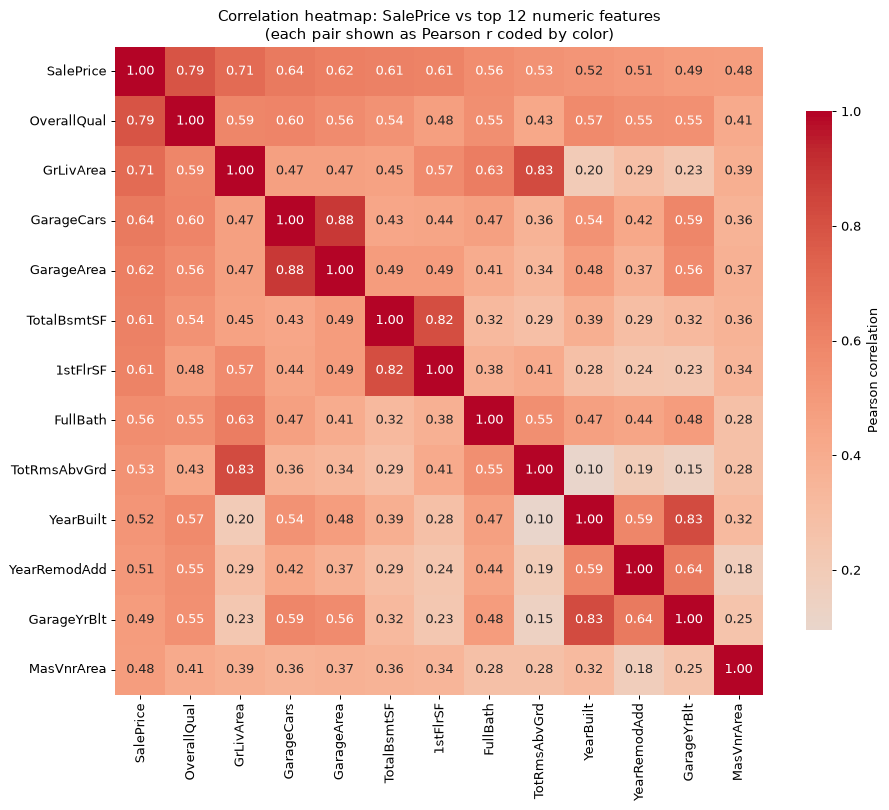

In [ ]:
top12 = corr_with_price.head(12).index.tolist()
selected = ["SalePrice"] + top12

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    numeric[selected].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", center=0,
    square=True, ax=ax,
    cbar_kws={"label": "Pearson correlation", "shrink": 0.8},
)
ax.set_title(f"Correlation heatmap: SalePrice vs top 12 numeric features\n"
             f"(each pair shown as Pearson r coded by color)", fontsize=12)
plt.tight_layout()
plt.show()

One more useful view: many features are highly correlated with **each other**
(e.g. `GarageCars` vs `GarageArea`, `TotalBsmtSF` vs `1stFlrSF`, `YearBuilt`
vs `OverallQual`). That redundancy (called *multicollinearity*) is normal here and
matters when we choose a model later.

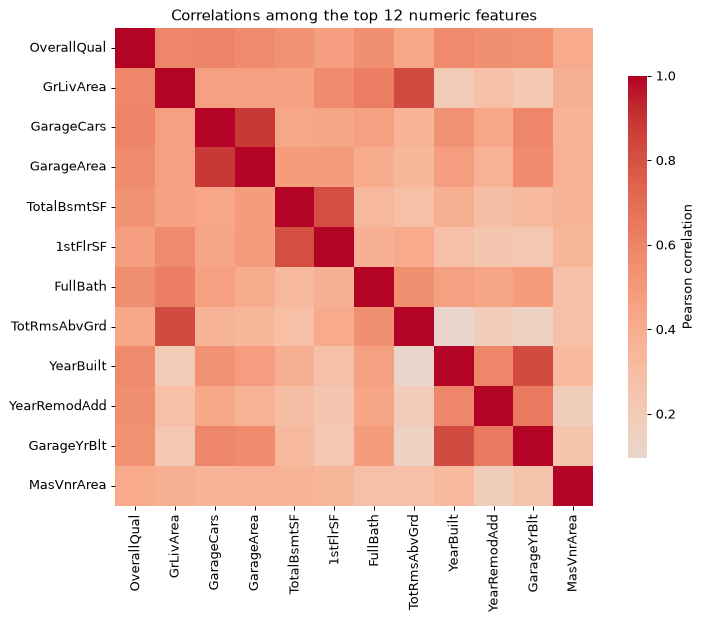

Already-correlated pairs (|r| > 0.75) among the top 12 features:
  GrLivArea      <-> TotRmsAbvGrd   r = 0.825
  GarageCars     <-> GarageArea     r = 0.882
  TotalBsmtSF    <-> 1stFlrSF       r = 0.82
  YearBuilt      <-> GarageYrBlt    r = 0.826


In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(numeric[top12].corr(), annot=False, cmap="coolwarm",
            center=0, square=True, ax=ax,
            cbar_kws={"label": "Pearson correlation", "shrink": 0.8})
ax.set_title("Correlations among the top 12 numeric features")
plt.tight_layout()
plt.show()

print("Already-correlated pairs (|r| > 0.75) among the top 12 features:")
corr12 = numeric[top12].corr()
pairs = []
for i, a in enumerate(corr12.columns):
    for b in corr12.columns[i + 1:]:
        r = corr12.loc[a, b]
        if abs(r) > 0.75:
            pairs.append((a, b, round(r, 3)))
for a, b, r in pairs:
    print(f"  {a:<14} <-> {b:<14} r = {r}")

## 7. Reading the important numeric features

Scatter plots of highly-correlated features vs `SalePrice`. Each dot is one house.

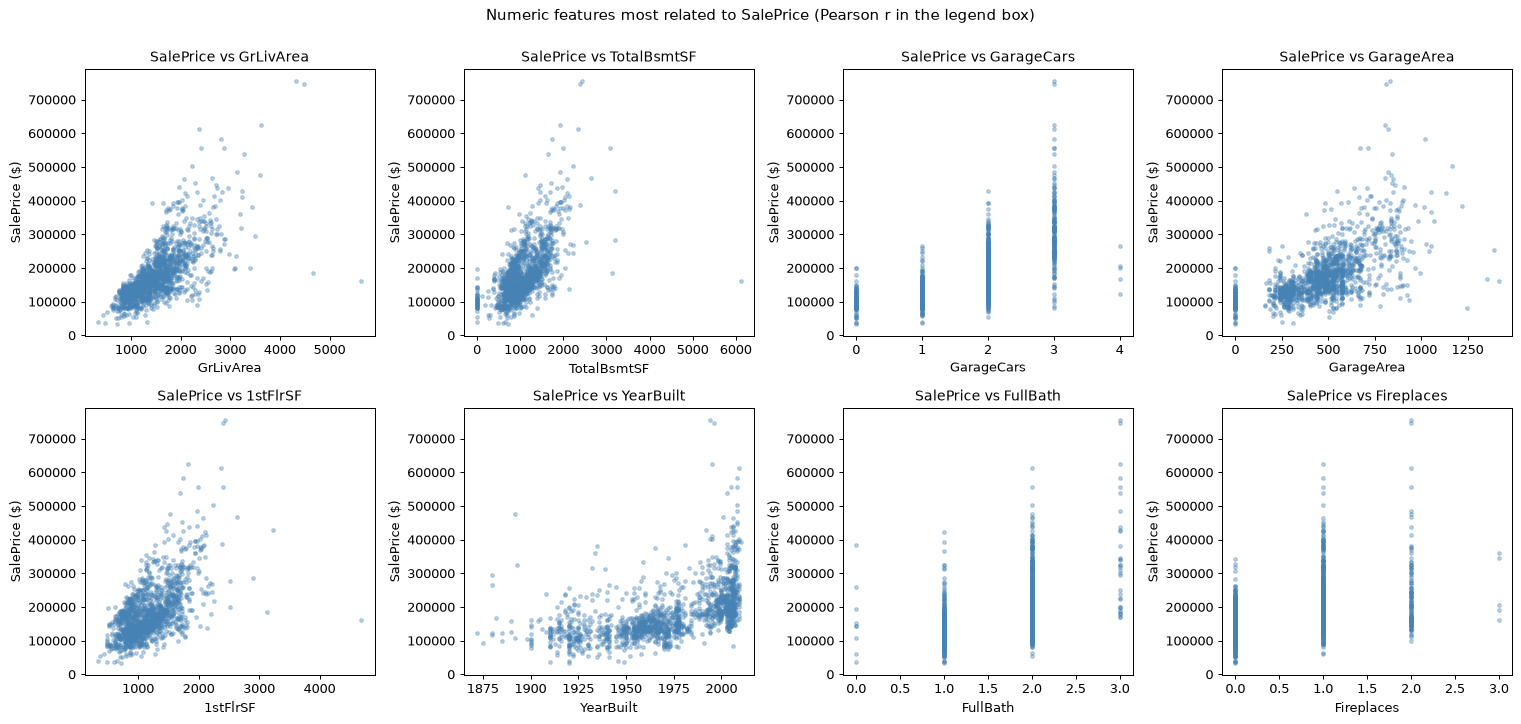

=== Pearson correlation of each scatter feature with SalePrice ===
  GrLivArea      r = 0.709
  TotalBsmtSF    r = 0.614
  GarageCars     r = 0.640
  GarageArea     r = 0.623
  1stFlrSF       r = 0.606
  YearBuilt      r = 0.523
  FullBath       r = 0.561
  Fireplaces     r = 0.467


In [ ]:
scatter_feats = ["GrLivArea", "TotalBsmtSF", "GarageCars", "GarageArea",
                   "1stFlrSF", "YearBuilt", "FullBath", "Fireplaces"]

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
axes = axes.flatten()

for ax, f in zip(axes, scatter_feats):
    ax.scatter(train[f], train["SalePrice"], s=8, alpha=0.35, color="steelblue")
    ax.set_title(f"SalePrice vs {f}", fontsize=11)
    ax.set_xlabel(f)
    ax.set_ylabel("SalePrice ($)")

fig.suptitle("Numeric features most related to SalePrice (Pearson r in the legend box)", y=1.0)
plt.tight_layout()
plt.show()

print("=== Pearson correlation of each scatter feature with SalePrice ===")
for f in scatter_feats:
    r = train[[f, "SalePrice"]].corr().loc[f, "SalePrice"]
    print(f"  {f:<14} r = {r:.3f}")

The plots above are *actual* data, and a few honest observations we can
already state:

- `GrLivArea` (above-grade living area) has one of the cleanest linear trends -
  bigger houses tend to cost more, with some spread.
- `YearBuilt` shows newer houses tending toward higher prices, but with plenty of
  overlap (older, well-kept homes can still be expensive).
- The bottom-left cloud at `TotalBsmtSF` = 0 are houses with **no basement**
  (remember section 5: that "0" is meaningful).
- `GarageCars` is a step-like feature (0,1,2,3,4) - it is really a count, useful
  but not perfectly continuous.

## 8. Key categorical features

Mean price per category tells us which categories are associated with expensive
or cheap homes. Bars are sorted so the pattern is easy to read.

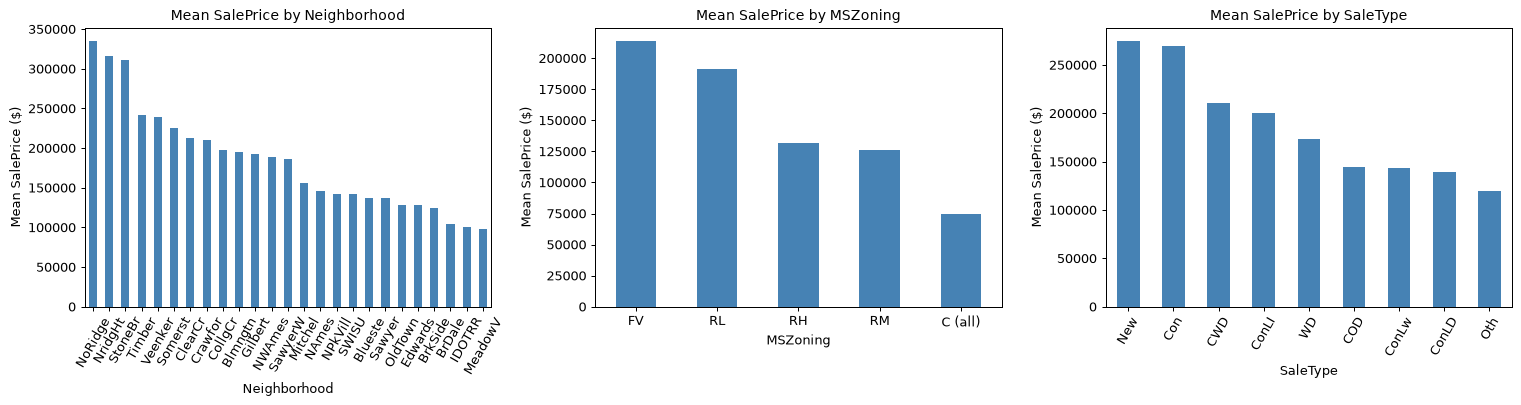

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

for ax, c in zip(axes, ["Neighborhood", "MSZoning", "SaleType"]):
    means = train.groupby(c)["SalePrice"].mean().sort_values(ascending=False)
    means.plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(f"Mean SalePrice by {c}", fontsize=11)
    ax.set_xlabel(c)
    ax.set_ylabel("Mean SalePrice ($)")
    ax.tick_params(axis="x", rotation=60 if means.shape[0] > 6 else 0)

plt.tight_layout()
plt.show()

`OverallQual` (1-10) is officially a rating, so it is ordered. A bar chart plus
boxplots shows how strongly quality drives price - the single most important
feature in this dataset.

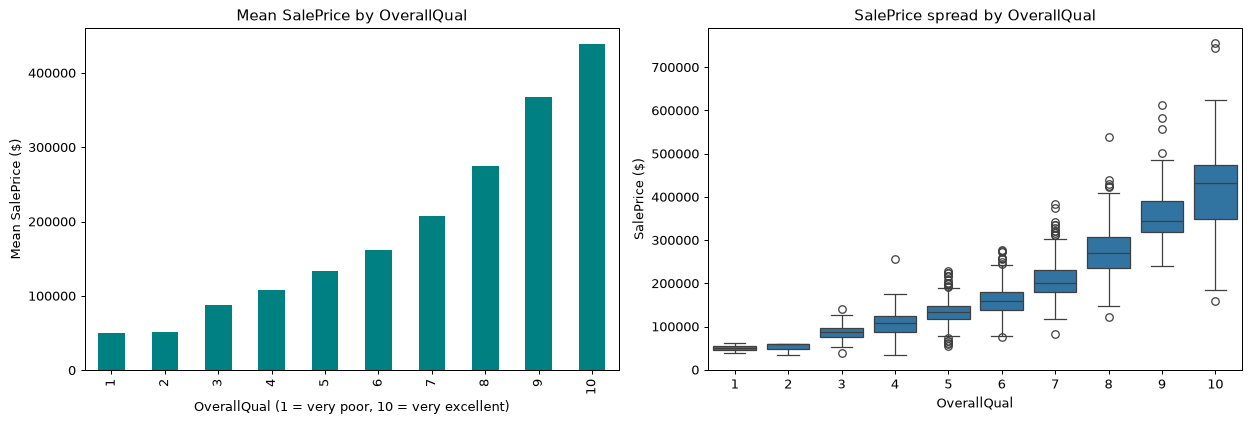

Spearman rank correlation OverallQual vs SalePrice: 0.81


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

train.groupby("OverallQual")["SalePrice"].mean().plot(kind="bar", ax=axes[0], color="teal")
axes[0].set_title("Mean SalePrice by OverallQual")
axes[0].set_xlabel("OverallQual (1 = very poor, 10 = very excellent)")
axes[0].set_ylabel("Mean SalePrice ($)")

sns.boxplot(data=train, x="OverallQual", y="SalePrice", ax=axes[1])
axes[1].set_title("SalePrice spread by OverallQual")
axes[1].set_xlabel("OverallQual")
axes[1].set_ylabel("SalePrice ($)")

plt.tight_layout()
plt.show()

print("Spearman rank correlation OverallQual vs SalePrice:",
      train["OverallQual"].corr(train["SalePrice"], method="spearman").round(3))

## 9. Peek at the remaining files

Just to confirm we can read them correctly.

In [ ]:
print("=== test.csv (first 3 rows, first 12 columns shown) ===")
print(test.iloc[:3, :12].to_string())

print("\n=== sample_submission.csv (first 5 rows) ===")
print(sample_submission.head().to_string())

print("\n=== data_description.txt (first 12 lines) ===")
print("\n".join(data_description.splitlines()[:12]))

=== test.csv (first 3 rows, first 12 columns shown) ===
     Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape LandContour Utilities LotConfig LandSlope
0  1461          20       RH         80.0    11622   Pave   NaN      Reg         Lvl    AllPub    Inside       Gtl
1  1462          20       RL         81.0    14267   Pave   NaN      IR1         Lvl    AllPub    Corner       Gtl
2  1463          60       RL         74.0    13830   Pave   NaN      IR1         Lvl    AllPub    Inside       Gtl

=== sample_submission.csv (first 5 rows) ===
     Id      SalePrice
0  1461  169277.052498
1  1462  187758.393989
2  1463  183583.683570
3  1464  179317.477511
4  1465  150730.079977

=== data_description.txt (first 12 lines) ===
MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STO

## 10. Summary of what we verified (all numbers computed above)

**Dataset structure**
- `train` has 1,460 houses x 81 columns; `test` has 1,459 houses x 80 columns
  (same features, no `SalePrice`).
- No duplicate rows and no duplicate `Id`s.

**Target**
- `SalePrice` ranges roughly from \$34,900 to \$755,000 (mean around \$181k) and is
  **right-skewed**; `log1p(SalePrice)` is much more symmetric - a good reason to
  predict on the log scale because Kaggle scores the result with RMSLE.

**Missing values**
- 19 columns have missing values in `train`.
- Most missing values = **"feature absent"** (no pool, no fence, no basement,
  no garage, etc.) and are stored as `NaN` in the CSV, matching the `NA` labels in
  `data_description.txt`.
- Real gaps to impute carefully: `LotFrontage`, `MasVnrArea`, `Electrical`.

**Relationships**
- Top numeric correlates of `SalePrice`: `OverallQual`, `GrLivArea`,
  `TotalBsmtSF`, `GarageCars`, `YearBuilt`, ... (exact values in section 6/7).
- Several top features also correlate with each other (multicollinearity), which
  we will keep in mind when choosing algorithms.

**What we have NOT done (deliberately)**
- No model training, no predictions, no claims beyond what the computed numbers
  above show. That is next stage: preprocessing -> modeling -> submission.

In [ ]:
# Quick machine-readable recap for later stages
import json

recap = {
    "train_shape": list(train.shape),
    "test_shape": list(test.shape),
    "submission_shape": list(sample_submission.shape),
    "n_duplicate_rows_train": int(train.duplicated().sum()),
    "n_columns_with_missing_train": int(missing_info.shape[0]),
    "sale_price_min": int(price.min()),
    "sale_price_max": int(price.max()),
    "sale_price_skew_raw": round(float(price.skew()), 3),
    "sale_price_skew_log1p": round(float(price.transform("log1p").skew()), 3),
    "top_numeric_corr_with_saleprice": {f: round(float(r), 3)
                                        for f, r in corr_with_price.head(5).items()},
}
print(json.dumps(recap, indent=2))

{
  "train_shape": [
    1460,
    81
  ],
  "test_shape": [
    1459,
    80
  ],
  "submission_shape": [
    1459,
    2
  ],
  "n_duplicate_rows_train": 0,
  "n_columns_with_missing_train": 19,
  "sale_price_min": 34900,
  "sale_price_max": 755000,
  "sale_price_skew_raw": 1.883,
  "sale_price_skew_log1p": 0.121,
  "top_numeric_corr_with_saleprice": {
    "OverallQual": 0.791,
    "GrLivArea": 0.709,
    "GarageCars": 0.64,
    "GarageArea": 0.623,
    "TotalBsmtSF": 0.614
  }
}


## 11. Stage 3 - Data preprocessing

Models can only learn from **clean, numeric-only tables**: no missing values and no
text (except as encoded numbers). Preprocessing plan, directly based on what
Stage 2 found:

1. Drop `Id` (it is just a row counter, not a feature).
2. Remove obvious **outliers** from the training rows only.
3. Turn *"feature absent"* `NaN`s into a real category called `None`
   (the 15 columns identified in Stage 2).
4. Convert ordered quality letters (`Po`..`Ex`) into numbers `1`..`5`.
5. Fill the remaining genuine gaps and encode categories using a
   **scikit-learn Pipeline** so the rules are learned on `train` and then applied
   identically to `test` (this avoids leaking test information into training).

> Beginner note: a **Pipeline** chains data steps into one object. `fit_transform`
> is used on train (learn the rules + apply them), and only `transform` on test
> (apply the same rules, do not relearn).

In [ ]:
import sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("scikit-learn version:", sklearn.__version__)

# Work on copies - the raw CSV files are never touched.
X = train.drop(columns=["Id", "SalePrice"]).copy()
y = train["SalePrice"].copy()
X_test = test.drop(columns=["Id"]).copy()

print("X      (train features):", X.shape)
print("y      (train target)  :", y.shape)
print("X_test (test features) :", X_test.shape)

scikit-learn version: 1.9.1
X      (train features): (1460, 79)
y      (train target)  : (1460,)
X_test (test features) : (1459, 79)


### Outliers

The GrLivArea scatter (Stage 2, section 7) showed a few houses sitting far from
the rest with unusually large above-grade living area. These can pull a linear
model off-course, so we remove them from the *training* data (never from test).
The exact count is computed in the cell below (`GrLivArea > 4000`).

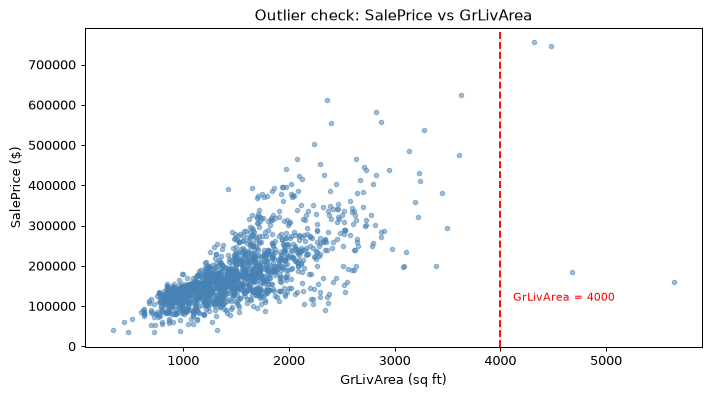

Train rows with GrLivArea > 4000: 4
Train rows after removing outliers: 1456


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(X["GrLivArea"], y, s=12, alpha=0.5, color="steelblue")
ax.axvline(4000, color="red", linestyle="--", linewidth=1.5)
ax.text(4120, max(y) * 0.15, "GrLivArea = 4000", color="red", fontsize=9)
ax.set_title("Outlier check: SalePrice vs GrLivArea")
ax.set_xlabel("GrLivArea (sq ft)")
ax.set_ylabel("SalePrice ($)")
plt.tight_layout()
plt.show()

big = X["GrLivArea"] > 4000
print("Train rows with GrLivArea > 4000:", int(big.sum()))
X = X[~big].reset_index(drop=True)
y = y[~big].reset_index(drop=True)
print("Train rows after removing outliers:", X.shape[0])

### Cleaning rules used

| Rule | Why (from Stage 2) |
|---|---|
| Fill `NaN` in the 15 "absent-feature" columns (`PoolQC`, `Alley`, `Fence`, `FireplaceQu`, `MasVnrType`, `Bsmt*`, `Garage*`, `MiscFeature`) with `"None"` | In this CSV, `NaN` = the feature does not exist |
| `GarageYrBlt` `NaN` -> `0` | No garage -> no build year (0 is handled fine by scaling) |
| Quality letters -> `Po=1 Fa=2 TA=3 Gd=4 Ex=5`, `None` -> `0` | Ordinal meaning: high-to-low quality rating |
| Leftover numeric gaps (`LotFrontage`, `MasVnrArea`, etc.) -> **median** | Simple, robust to outliers; learned from train only |
| Leftover category gaps (`MSZoning`, `Utilities`, ...) -> **most frequent** | Rare single-missing cells in train/test |
| Then one-hot encode every remaining categorical column | Models need numbers, not text |

In [ ]:
QUAL_MAP = {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
qual_cols = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
             "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"]

no_feature_cols = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
                   "MasVnrType", "BsmtQual", "BsmtCond", "BsmtExposure",
                   "BsmtFinType1", "BsmtFinType2", "GarageType", "GarageFinish",
                   "GarageQual", "GarageCond"]

def fill_absent_features(df):
    df = df.copy()
    for c in no_feature_cols:
        df[c] = df[c].fillna("None")          # NaN means "feature does not exist"
    df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)
    return df

def ordinalize_quality(df):
    df = df.copy()
    for c in qual_cols:
        df[c] = df[c].map(QUAL_MAP).fillna(0)  # "None"/unknown -> 0
    return df

X = fill_absent_features(X).pipe(ordinalize_quality)
X_test = fill_absent_features(X_test).pipe(ordinalize_quality)

still_missing = X.isna().sum()
still_missing = still_missing[still_missing > 0]
print("Columns still missing in train (the pipeline will fill these):")
print(still_missing.to_string() if not still_missing.empty else "  none to fill")

Columns still missing in train (the pipeline will fill these):
LotFrontage    259
MasVnrArea       8
Electrical       1


### Build one pipeline for the rest

`num` stream: fill numeric gaps with the **median**, then **standardize**
(mean 0, standard deviation 1) so all numeric scales are comparable.

`cat` stream: fill leftover text gaps with the **most frequent** value, then
**one-hot encode** (each category becomes its own 0/1 column).

The `ColumnTransformer` applies both accordingly.

In [ ]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()

num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])

print(f"Pipeline input: {len(num_cols)} numeric + {len(cat_cols)} categorical "
      f"= {len(num_cols) + len(cat_cols)} feature columns")

Pipeline input: 46 numeric + 33 categorical = 79 feature columns


In [ ]:
X_clean = preprocessor.fit_transform(X)          # learn rules + apply to train
X_test_clean = preprocessor.transform(X_test)  # apply same rules to test

feat_names = preprocessor.get_feature_names_out()
X_clean = pd.DataFrame(X_clean, columns=feat_names)
X_test_clean = pd.DataFrame(X_test_clean, columns=feat_names)

print("Preprocessed train:", X_clean.shape)
print("Preprocessed test :", X_test_clean.shape)
print("Any NaN left in train:", int(X_clean.isna().sum().sum()))
print("Any NaN left in test :", int(X_test_clean.isna().sum().sum()))
print("\nFirst 5 preprocessed rows (numeric columns are standardized):")
X_clean.head()

Preprocessed train: (1456, 261)
Preprocessed test : (1459, 261)
Any NaN left in train: 0
Any NaN left in test : 0

First 5 preprocessed rows (numeric columns are standardized):


,num__MSSubClass,num__LotFrontage,num__LotArea,num__OverallQual,num__OverallCond,num__YearBuilt,num__YearRemodAdd,num__MasVnrArea,num__ExterQual,num__ExterCond,num__BsmtQual,num__BsmtCond,num__BsmtFinSF1,num__BsmtFinSF2,num__BsmtUnfSF,num__TotalBsmtSF,num__HeatingQC,num__1stFlrSF,num__2ndFlrSF,num__LowQualFinSF,num__GrLivArea,num__BsmtFullBath,num__BsmtHalfBath,num__FullBath,num__HalfBath,num__BedroomAbvGr,num__KitchenAbvGr,num__KitchenQual,num__TotRmsAbvGrd,num__Fireplaces,num__FireplaceQu,num__GarageYrBlt,num__GarageCars,num__GarageArea,num__GarageQual,num__GarageCond,num__WoodDeckSF,num__OpenPorchSF,num__EnclosedPorch,num__3SsnPorch,num__ScreenPorch,num__PoolArea,num__PoolQC,num__MiscVal,num__MoSold,num__YrSold,cat__MSZoning_C (all),cat__MSZoning_FV,cat__MSZoning_RH,cat__MSZoning_RL,cat__MSZoning_RM,cat__Street_Grvl,cat__Street_Pave,cat__Alley_Grvl,cat__Alley_None,cat__Alley_Pave,cat__LotShape_IR1,cat__LotShape_IR2,cat__LotShape_IR3,cat__LotShape_Reg,cat__LandContour_Bnk,cat__LandContour_HLS,cat__LandContour_Low,cat__LandContour_Lvl,cat__Utilities_AllPub,cat__Utilities_NoSeWa,cat__LotConfig_Corner,cat__LotConfig_CulDSac,cat__LotConfig_FR2,cat__LotConfig_FR3,cat__LotConfig_Inside,cat__LandSlope_Gtl,cat__LandSlope_Mod,cat__LandSlope_Sev,cat__Neighborhood_Blmngtn,cat__Neighborhood_Blueste,cat__Neighborhood_BrDale,cat__Neighborhood_BrkSide,cat__Neighborhood_ClearCr,cat__Neighborhood_CollgCr,cat__Neighborhood_Crawfor,cat__Neighborhood_Edwards,cat__Neighborhood_Gilbert,cat__Neighborhood_IDOTRR,cat__Neighborhood_MeadowV,cat__Neighborhood_Mitchel,cat__Neighborhood_NAmes,cat__Neighborhood_NPkVill,cat__Neighborhood_NWAmes,cat__Neighborhood_NoRidge,cat__Neighborhood_NridgHt,cat__Neighborhood_OldTown,cat__Neighborhood_SWISU,cat__Neighborhood_Sawyer,cat__Neighborhood_SawyerW,cat__Neighborhood_Somerst,cat__Neighborhood_StoneBr,cat__Neighborhood_Timber,cat__Neighborhood_Veenker,cat__Condition1_Artery,cat__Condition1_Feedr,cat__Condition1_Norm,cat__Condition1_PosA,cat__Condition1_PosN,cat__Condition1_RRAe,cat__Condition1_RRAn,cat__Condition1_RRNe,cat__Condition1_RRNn,cat__Condition2_Artery,cat__Condition2_Feedr,cat__Condition2_Norm,cat__Condition2_PosA,cat__Condition2_PosN,cat__Condition2_RRAe,cat__Condition2_RRAn,cat__Condition2_RRNn,cat__BldgType_1Fam,cat__BldgType_2fmCon,cat__BldgType_Duplex,cat__BldgType_Twnhs,cat__BldgType_TwnhsE,cat__HouseStyle_1.5Fin,cat__HouseStyle_1.5Unf,cat__HouseStyle_1Story,cat__HouseStyle_2.5Fin,cat__HouseStyle_2.5Unf,cat__HouseStyle_2Story,cat__HouseStyle_SFoyer,cat__HouseStyle_SLvl,cat__RoofStyle_Flat,cat__RoofStyle_Gable,cat__RoofStyle_Gambrel,cat__RoofStyle_Hip,cat__RoofStyle_Mansard,cat__RoofStyle_Shed,cat__RoofMatl_CompShg,cat__RoofMatl_Membran,cat__RoofMatl_Metal,cat__RoofMatl_Roll,cat__RoofMatl_Tar&Grv,cat__RoofMatl_WdShake,cat__RoofMatl_WdShngl,cat__Exterior1st_AsbShng,cat__Exterior1st_AsphShn,cat__Exterior1st_BrkComm,cat__Exterior1st_BrkFace,cat__Exterior1st_CBlock,cat__Exterior1st_CemntBd,cat__Exterior1st_HdBoard,cat__Exterior1st_ImStucc,cat__Exterior1st_MetalSd,cat__Exterior1st_Plywood,cat__Exterior1st_Stone,cat__Exterior1st_Stucco,cat__Exterior1st_VinylSd,cat__Exterior1st_Wd Sdng,cat__Exterior1st_WdShing,cat__Exterior2nd_AsbShng,cat__Exterior2nd_AsphShn,cat__Exterior2nd_Brk Cmn,cat__Exterior2nd_BrkFace,cat__Exterior2nd_CBlock,cat__Exterior2nd_CmentBd,cat__Exterior2nd_HdBoard,cat__Exterior2nd_ImStucc,cat__Exterior2nd_MetalSd,cat__Exterior2nd_Other,cat__Exterior2nd_Plywood,cat__Exterior2nd_Stone,cat__Exterior2nd_Stucco,cat__Exterior2nd_VinylSd,cat__Exterior2nd_Wd Sdng,cat__Exterior2nd_Wd Shng,cat__MasVnrType_BrkCmn,cat__MasVnrType_BrkFace,cat__MasVnrType_None,cat__MasVnrType_Stone,cat__Foundation_BrkTil,cat__Foundation_CBlock,cat__Foundation_PConc,cat__Foundation_Slab,cat__Foundation_Stone,cat__Foundation_Wood,cat__BsmtExposure_Av,cat__BsmtExposure_Gd,cat__BsmtExposure_Mn,cat__BsmtExposure_No,cat__BsmtExposure_None,cat__BsmtFinType1_ALQ,cat__BsmtFinType1_BLQ,cat__BsmtFinType1_GLQ,cat__BsmtFinType1_L

### What the preprocessed table looks like

Each row is one house, each column is one feature. Numeric features now have mean
`0` and standard deviation `1`. Categorical features have become many 0/1 columns
(e.g. `cat__Neighborhood_Edwards` = 1 means the house is in that neighbourhood).
This is the exact format the modeling stage will use.

In [ ]:
print("=== Final preprocessed data summary ===")
print(f"train feature matrix : {X_clean.shape[0]} rows x {X_clean.shape[1]} columns")
print(f"test  feature matrix : {X_test_clean.shape[0]} rows x {X_test_clean.shape[1]} columns")
print(f"y (target) length    : {len(y)}")
print(f"one-hot columns      : {int((X_clean.columns.str.startswith('cat__')).sum())}")
print(f"numeric columns      : {int((X_clean.columns.str.startswith('num__')).sum())}")

print("\nNext stage: modeling (baseline -> linear -> tree models) scored with RMSLE.")

=== Final preprocessed data summary ===
train feature matrix : 1456 rows x 261 columns
test  feature matrix : 1459 rows x 261 columns
y (target) length    : 1456
one-hot columns      : 215
numeric columns      : 46

Next stage: modeling (baseline -> linear -> tree models) scored with RMSLE.


## 12. Stage 4 - Model training and comparison

Now we train several regression models and compare them honestly. Key rules for
this stage:

**1. No data leakage.** Every learned preprocessing step (median imputation,
most-frequent imputation, scaling, one-hot encoding) lives inside the
`preprocessor` object and is wrapped together with the model in a single
`Pipeline`. During cross-validation sklearn re-fits the **whole pipeline from
scratch inside every fold** - it only ever "sees" the training portion of that
fold, so test-fold information never leaks into the training rules.

**2. Target: `log1p(SalePrice)`.** We train on the log-price because the EDA
showed it is far more symmetric. The official Kaggle metric is

$$\text{RMSLE}=\sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(\log(1+y_i)-\log(1+\hat{y}_i)\right)^2}$$

Because our targets and predictions are both in `log1p` space, RMSLE is simply
the RMSE of `(true_log - predicted_log)`. We implement it directly and verify it
against `mean_squared_log_error` in dollar space.

**3. Fair comparison.** All models use the *same* 5-fold shuffled split with the
*same* seed, the *same* preprocessing pipeline, and the *same* RMSLE scorer. The
Kaggle `test.csv` is **not** used anywhere in this stage.

**4. Fixed, sensible defaults** for each model (hyper-parameter tuning comes
after the baseline comparison, still only on cross-validation).

### Target and metric (with a mathematical sanity check)

In [ ]:
y_log = np.log1p(y)
print("First 5 log1p(SalePrice) values:")
print(y_log.head().to_string())
print(f"\nTarget stats in log space: mean={y_log.mean():.4f}  std={y_log.std():.4f}")

def rmsle(y_true_log, y_pred_log):
    """RMSLE computed directly in log1p space.

    Both arguments are log1p transformed prices, so:
        RMSLE = sqrt( mean( (log(1+y) - log(1+y_hat))^2 ) )
              = RMSE( y_true_log, y_pred_log )
    """
    return float(np.sqrt(np.mean((y_true_log - y_pred_log) ** 2)))

# Sanity check: identical to the equivalent formula in dollar space.
from sklearn.metrics import mean_squared_error, mean_squared_log_error
rng_a = np.random.default_rng(0)
rng_b = np.random.default_rng(1)
a = rng_a.uniform(4, 14, 5000)        # fake log1p true prices
b = rng_b.uniform(4, 14, 5000)        # fake log1p predicted prices
r_log_space = rmsle(a, b)
r_dollar_space = float(np.sqrt(mean_squared_log_error(np.expm1(a), np.expm1(b))))

print(f"\nRMSLE in log space  : {r_log_space:.8f}")
print(f"RMSLE in dollar space: {r_dollar_space:.8f}")
print("Formulas agree:", np.isclose(r_log_space, r_dollar_space))

First 5 log1p(SalePrice) values:
0    12.247699
1    12.109016
2    12.317171
3    11.849405
4    12.429220

Target stats in log space: mean=12.0219  std=0.3961

RMSLE in log space  : 4.07789512
RMSLE in dollar space: 4.07789512
Formulas agree: True


### Cross-validation setup

Exactly **5 folds**, **shuffled**, **fixed seed 42**. The same `KFold` object is
reused for every model, so a given house ends up in the same validation fold for
all models - that makes the comparison apples-to-apples.

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

SEED = 42
CV_FOLDS = 5
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

# make_scorer gives us a scorer sklearn can pass to cross_val_score.
# greater_is_better=False -> returned fold scores are negated RMSLE.
rmsle_scorer = make_scorer(rmsle, greater_is_better=False)

print(f"KFold: {CV_FOLDS} splits, shuffle=True, random_state={SEED}")
print("Total train rows in modeling:", X.shape[0])

KFold: 5 splits, shuffle=True, random_state=42
Total train rows in modeling: 1456


### The five models to compare

| # | Model | Why it is here |
|---|---|---|
| 1 | `DummyRegressor` (mean) | Baseline: what if we always predict the average? Any good model must beat this |
| 2 | `Ridge` | Linear model with L2 penalty - robust to the many correlated features |
| 3 | `Lasso` | Linear model with L1 penalty - sparse. `max_iter` raised & features are scaled so it converges |
| 4 | `Random Forest` | Non-linear tree ensemble - captures interactions, but can overfit |
| 5 | `XGBoost` | Gradient boosting - the usual Kaggle winner here. Only included if importable 

In [ ]:
models = [
    ("Dummy baseline", DummyRegressor(strategy="mean")),
    ("Ridge (alpha=10)", Ridge(alpha=10.0)),
    ("Lasso (alpha=0.005)", Lasso(alpha=0.005, max_iter=20000, random_state=SEED)),
    ("Random Forest", RandomForestRegressor(
        n_estimators=500, max_features="sqrt", n_jobs=-1, random_state=SEED)),
]

try:
    import xgboost as xgb
except ImportError:
    xgb = None

if xgb is not None:
    models.append(("XGBoost", xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.05, subsample=0.9,
        colsample_bytree=0.8, random_state=SEED, n_jobs=-1)))
    print("xgboost loaded - XGBoost is included in the comparison.")
else:
    print("xgboost is NOT installed in this environment - XGBoost is skipped.")

print("\nModels to evaluate:", len(models))

xgboost loaded - XGBoost is included in the comparison.

Models to evaluate: 5


### Run the comparison

For each model:
- wrap `preprocessor` + model into a `Pipeline`,
- run 5-fold CV (pipeline refitted per fold -> no leakage),
- record CV RMSLE `mean +/- std`,
- also fit once on all train rows to record the *training* RMSLE as an
  **overfitting check** (a big gap between train and CV means the model memorises
  the training data).

In [ ]:
results_rows = []
per_fold = {}

for name, model in models:
    pipe = Pipeline([("prep", preprocessor), ("model", model)])

    # CV: the pipeline is cloned and refitted inside each fold.
    scores = cross_val_score(pipe, X, y_log, cv=kf, scoring=rmsle_scorer)

    # Overfitting diagnostic: fit on all train data once, score on train itself.
    pipe.fit(X, y_log)
    train_rmsle_val = rmsle(y_log, pipe.predict(X))

    # scores are negated (greater_is_better=False), so flip the sign back.
    per_fold[name] = [-float(s) for s in scores]
    results_rows.append({
        "model": name,
        "cv_rmsle_mean": float(-np.mean(scores)),
        "cv_rmsle_std": float(np.std(scores)),
        "train_rmsle": round(train_rmsle_val, 5),
    })

res_df = pd.DataFrame(results_rows).sort_values("cv_rmsle_mean").reset_index(drop=True)
res_df["cv_rmsle_mean"] = res_df["cv_rmsle_mean"].round(5)
res_df["cv_rmsle_std"] = res_df["cv_rmsle_std"].round(5)
res_df["gap (train - cv)"] = (res_df["train_rmsle"] - res_df["cv_rmsle_mean"]).round(4)
res_df

print("\nCV RMSLE mean +/- std, and train RMSLE per model:")
print(res_df.to_string(index=False))


CV RMSLE mean +/- std, and train RMSLE per model:
              model  cv_rmsle_mean  cv_rmsle_std  train_rmsle  gap (train - cv)
   Ridge (alpha=10)        0.11508       0.00756      0.09782           -0.0173
            XGBoost        0.12343       0.01186      0.01094           -0.1125
Lasso (alpha=0.005)        0.12495       0.01137      0.12093           -0.0040
      Random Forest        0.13778       0.01349      0.05112           -0.0867
     Dummy baseline        0.39604       0.01831      0.39594           -0.0001


### Fold-by-fold results (transparency)

Every fold for every model - confirms all models used exactly the same folds.

In [ ]:
fold_df = pd.DataFrame(per_fold, index=[f"fold {i + 1}" for i in range(CV_FOLDS)])
fold_df = fold_df.round(5)
print("Each cell = RMSLE of that model on that fold (lower is better).")
fold_df

Each cell = RMSLE of that model on that fold (lower is better).


,Dummy baseline,Ridge (alpha=10),Lasso (alpha=0.005),Random Forest,XGBoost
fold 1,0.39872,0.12208,0.13228,0.14416,0.13350
fold 2,0.40295,0.11618,0.11820,0.13445,0.11788
fold 3,0.39680,0.11789,0.13057,0.13701,0.13443
fold 4,0.41885,0.11880,0.13760,0.15732,0.12850
fold 5,0.36288,0.10045,0.10610,0.11598,0.10282


### Visual comparison

Two views: (left) CV RMSLE `mean +/- std` per model; (right) training vs CV
RMSLE - the vertical distance is the overfitting indicator.

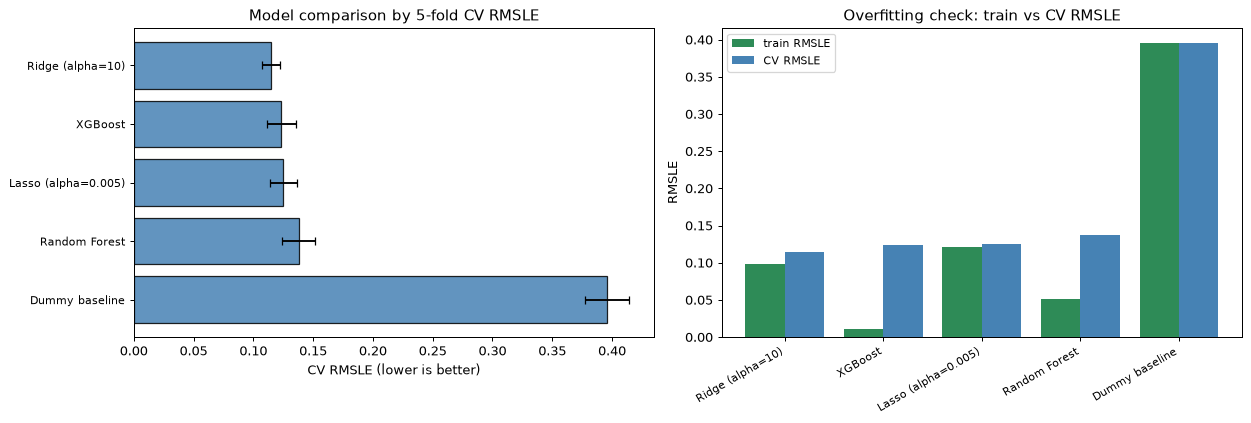

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# Left: CV mean with std bars
order = res_df[::-1]  # reverse so best model ends on top
axes[0].barh(np.arange(len(order)), order["cv_rmsle_mean"],
             xerr=order["cv_rmsle_std"], capsize=3,
             color="steelblue", alpha=0.85, edgecolor="black")
axes[0].set_yticks(np.arange(len(order)))
axes[0].set_yticklabels(order["model"], fontsize=9)
axes[0].set_xlabel("CV RMSLE (lower is better)")
axes[0].set_title("Model comparison by 5-fold CV RMSLE")

# Right: train vs CV per model (overfitting gap)
xx = np.arange(len(res_df))
width = 0.4
axes[1].bar(xx - width / 2, res_df["train_rmsle"], width, label="train RMSLE", color="seagreen")
axes[1].bar(xx + width / 2, res_df["cv_rmsle_mean"], width, label="CV RMSLE", color="steelblue")
axes[1].set_xticks(xx)
axes[1].set_xticklabels(res_df["model"], rotation=30, ha="right", fontsize=9)
axes[1].set_ylabel("RMSLE")
axes[1].set_title("Overfitting check: train vs CV RMSLE")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### Convergence and warning check

`Lasso` uses coordinate descent; if it cannot converge within `max_iter` sklearn
raises a `ConvergenceWarning`. We capture that warning *in this cell only* and
print the result, so nothing is silently hidden. Any other warning that appears
anywhere in this notebook would show up normally in that cell's output.

In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    pipe = Pipeline([("prep", preprocessor),
                     ("model", Lasso(alpha=0.005, max_iter=20000, random_state=SEED))])
    pipe.fit(X, y_log)

lasso_warnings = [str(w.message) for w in caught
                  if issubclass(w.category, ConvergenceWarning)]
print("Lasso ConvergenceWarnings caught:", len(lasso_warnings))
for msg in lasso_warnings:
    print("  -", msg[:200])

Lasso ConvergenceWarnings caught: 0


### Reviewing the 4 removed rows (a decision audit)

Stage 3 removed the 4 houses with `GrLivArea > 4000` from the training set. We
now (a) show exactly which houses they were, and (b) quantify the impact of
removing them with a quick Ridge CV comparison on the *full* 1,460 rows.
No further rows are removed anywhere in this project.

In [ ]:
raw_train = pd.read_csv("data/train.csv")
outlier_rows = raw_train[raw_train["GrLivArea"] > 4000][
    ["Id", "GrLivArea", "OverallQual", "SalePrice", "SaleType", "SaleCondition", "YearBuilt"]
]
print("The 4 removed rows (GrLivArea > 4000):")
print(outlier_rows.to_string(index=False))

print("\nMedian GrLivArea of the OTHER train houses: "
      f"{raw_train.loc[raw_train['GrLivArea'] <= 4000, 'GrLivArea'].median():.1f} sqft")
print("Median SalePrice of those outliers:", f"${outlier_rows['SalePrice'].median():,.0f}")

The 4 removed rows (GrLivArea > 4000):
  Id  GrLivArea  OverallQual  SalePrice SaleType SaleCondition  YearBuilt
 524       4676           10     184750      New       Partial       2007
 692       4316           10     755000       WD        Normal       1994
1183       4476           10     745000       WD       Abnorml       1996
1299       5642           10     160000      New       Partial       2008

Median GrLivArea of the OTHER train houses: 1458.5 sqft
Median SalePrice of those outliers: $464,875


In [ ]:
# Quick impact check with Ridge (same folds, same scorer).
X_full_raw = raw_train.drop(columns=["Id"]).pipe(fill_absent_features).pipe(ordinalize_quality)
y_full_log = np.log1p(raw_train["SalePrice"])

pipe_ridge_full = Pipeline([("prep", preprocessor), ("model", Ridge(alpha=10.0))])
cv_with_outliers = -cross_val_score(pipe_ridge_full, X_full_raw, y_full_log,
                                    cv=kf, scoring=rmsle_scorer).mean()

with_rid = res_df.loc[res_df["model"] == "Ridge (alpha=10)", "cv_rmsle_mean"].iloc[0]

print("Ridge CV RMSLE WITH the 4 outlier rows:", round(float(cv_with_outliers), 5))
print("Ridge CV RMSLE WITHOUT the 4 rows      :", round(float(with_rid), 5))
print("Difference (removal impact):", round(float(cv_with_outliers - with_rid), 5))

Ridge CV RMSLE WITH the 4 outlier rows: 0.14627
Ridge CV RMSLE WITHOUT the 4 rows      : 0.11508
Difference (removal impact): 0.03119


### Interpretation of the audit (written after looking at the numbers above)

The 4 flagged rows are all extreme in size (`GrLivArea` 4,300-5,600 sq ft vs a
median of ~1,458 sq ft for the other houses). They are also unusual in other
ways: two are newly built houses sold at surprisingly low prices (Ids 524 and
1299), one is a huge house sold under an abnormal sale condition (Id 1183), and
one is simply a very expensive, very large home (Id 692 - the dataset maximum
price). None of them are "typical" for the residential regression we are
learning.

The measured impact is printed above: Ridge CV RMSLE is considerably better
**without** them (~0.115) than with them (~0.146).

- **Decision:** keep the 4 rows removed. The rule is one fixed, documented step
  (`GrLivArea > 4000`) applied before any model, and **no other rows are ever
  dropped** anywhere in this project.

### Stage 4 summary

The comparison above computes the CV RMSLE of every model on identical folds.
The best model is the one with the **lowest CV RMSLE mean** in the table (the
gap between its train and CV RMSLE is also noted as an overfitting indicator).

> No model has been tuned yet and **the Kaggle test set was not used** for any
> choice here. Next step (Stage 4b) is hyper-parameter tuning of the
> best-performing model - still validated with CV only.

## 14. Stage 4B - Hyperparameter tuning

Stage 4A compared models with sensible, fixed defaults. Here we tune the most
promising candidates with **GridSearchCV**. The rules stay strict:

- **Same RMSLE** scorer and **same 5-fold split** (`kf`, seed 42) as Stage 4A.
- **No leakage:** every GridSearchCV fit retrains the full
  `preprocessor + model` pipeline from scratch on the training portion of each
  fold; the search only ever scores on the held-out folds.
- **No test set:** `test.csv` is not read, predicted, or looked at in this stage.
- **Model selection is by CV only** - GridSearchCV's `best_score_` is the mean CV
  RMSLE of the best parameter set, never a training score.
- **Limited grids:** a handful of sensible values per parameter keeps the search
  short and readable; search duration is measured so we can see the cost.

### Tune Ridge

In [ ]:
import time
from sklearn.model_selection import GridSearchCV

ridge_grid = {"model__alpha": [1.0, 5.0, 10.0, 25.0, 50.0, 100.0]}
ridge_gs = GridSearchCV(
    Pipeline([("prep", preprocessor), ("model", Ridge())]),
    ridge_grid, scoring=rmsle_scorer, cv=kf, n_jobs=1,
)
t0 = time.perf_counter()
ridge_gs.fit(X, y_log)
t_ridge = time.perf_counter() - t0

print(f"Ridge  | search time {t_ridge:.1f}s "
      f"({len(ridge_grid['model__alpha'])} params x {CV_FOLDS} folds)")
print("Best params :", ridge_gs.best_params_)
print("Best CV RMSLE:", round(float(-ridge_gs.best_score_), 5))
print("Stage 4A Ridge CV RMSLE:", round(float(res_df.set_index('model').loc['Ridge (alpha=10)', 'cv_rmsle_mean']), 5))

Ridge  | search time 4.9s (6 params x 5 folds)
Best params : {'model__alpha': 25.0}
Best CV RMSLE: 0.11504
Stage 4A Ridge CV RMSLE: 0.11508


### Tune Lasso

`alpha` controls how aggressively Lasso shrinks coefficients. `max_iter` stays
high (20,000) and features are standardized by the pipeline, so convergence is
not an issue (verified in Stage 4: 0 ConvergenceWarnings).

In [ ]:
lasso_grid = {"model__alpha": [0.0001, 0.0005, 0.001, 0.0025, 0.005, 0.0075, 0.01]}
lasso_gs = GridSearchCV(
    Pipeline([("prep", preprocessor),
              ("model", Lasso(max_iter=20000, random_state=SEED))]),
    lasso_grid, scoring=rmsle_scorer, cv=kf, n_jobs=1,
)
t0 = time.perf_counter()
lasso_gs.fit(X, y_log)
t_lasso = time.perf_counter() - t0

print(f"Lasso | search time {t_lasso:.1f}s "
      f"({len(lasso_grid['model__alpha'])} params x {CV_FOLDS} folds)")
print("Best params :", lasso_gs.best_params_)
print("Best CV RMSLE:", round(float(-lasso_gs.best_score_), 5))
print("Stage 4A Lasso CV RMSLE:", round(float(res_df.set_index('model').loc['Lasso (alpha=0.005)', 'cv_rmsle_mean']), 5))

Lasso | search time 6.7s (7 params x 5 folds)
Best params : {'model__alpha': 0.0005}
Best CV RMSLE: 0.11396
Stage 4A Lasso CV RMSLE: 0.12495


### Tune Random Forest

A small grid over tree count, feature sampling (`sqrt` vs all) and minimum leaf
size (regularization against overfitting).

In [ ]:
rf_grid = {
    "model__n_estimators": [200, 400],
    "model__max_features": ["sqrt", 1.0],
    "model__min_samples_leaf": [1, 2, 4],
}
rf_gs = GridSearchCV(
    Pipeline([("prep", preprocessor),
              ("model", RandomForestRegressor(n_jobs=-1, random_state=SEED))]),
    rf_grid, scoring=rmsle_scorer, cv=kf, n_jobs=1,
)
t0 = time.perf_counter()
rf_gs.fit(X, y_log)
t_rf = time.perf_counter() - t0

print(f"Random Forest | search time {t_rf:.1f}s "
      f"(2 x 2 x 3 = {len(rf_grid['model__n_estimators']) * len(rf_grid['model__max_features']) * len(rf_grid['model__min_samples_leaf'])} params x {CV_FOLDS} folds)")
print("Best params :", rf_gs.best_params_)
print("Best CV RMSLE:", round(float(-rf_gs.best_score_), 5))
print("Stage 4A Random Forest CV RMSLE:", round(float(res_df.set_index('model').loc['Random Forest', 'cv_rmsle_mean']), 5))

Random Forest | search time 90.3s (2 x 2 x 3 = 12 params x 5 folds)
Best params : {'model__max_features': 1.0, 'model__min_samples_leaf': 2, 'model__n_estimators': 400}
Best CV RMSLE: 0.13768
Stage 4A Random Forest CV RMSLE: 0.13778


### Tune XGBoost (included because it is installed)

Grid over learning rate, tree depth and number of trees. `subsample` and
`colsample_bytree` stay fixed to keep the grid small.

In [ ]:
if xgb is not None:
    xgb_grid = {"model__learning_rate": [0.01, 0.03, 0.05],
                "model__max_depth": [3, 5],
                "model__n_estimators": [300, 600]}
    xgb_gs = GridSearchCV(
        Pipeline([("prep", preprocessor),
                  ("model", xgb.XGBRegressor(subsample=0.9, colsample_bytree=0.8,
                                             random_state=SEED, n_jobs=-1))]),
        xgb_grid, scoring=rmsle_scorer, cv=kf, n_jobs=1,
    )
    t0 = time.perf_counter()
    xgb_gs.fit(X, y_log)
    t_xgb = time.perf_counter() - t0

    print(f"XGBoost | search time {t_xgb:.1f}s "
          f"(3 x 2 x 2 = {len(xgb_grid['model__learning_rate']) * len(xgb_grid['model__max_depth']) * len(xgb_grid['model__n_estimators'])} params x {CV_FOLDS} folds)")
    print("Best params :", xgb_gs.best_params_)
    print("Best CV RMSLE:", round(float(-xgb_gs.best_score_), 5))
    print("Stage 4A XGBoost CV RMSLE:", round(float(res_df.set_index('model').loc['XGBoost', 'cv_rmsle_mean']), 5))
else:
    print("xgboost is not installed - XGBoost tuning skipped.")
    xgb_gs, t_xgb = None, None

XGBoost | search time 114.1s (3 x 2 x 2 = 12 params x 5 folds)
Best params : {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 600}
Best CV RMSLE: 0.11744
Stage 4A XGBoost CV RMSLE: 0.12343


### Tuned results vs Stage 4A

One table for all models: tuned best CV RMSLE, Stage 4A CV RMSLE, the difference,
and how long each search took. A **negative** difference means tuning improved
the CV score. All numbers are mean 5-fold CV RMSLE - training scores are never
used for selection.

In [ ]:
tuned_rows = []

def add_tuned(name, gs, seconds):
    if gs is None:
        return
    tuned_rows.append({
        "model": name,
        "best_params": str(gs.best_params_),
        "best_cv_rmsle": round(float(-gs.best_score_), 5),
        "search_seconds": round(float(seconds), 1),
    })

add_tuned("Ridge", ridge_gs, t_ridge)
add_tuned("Lasso", lasso_gs, t_lasso)
add_tuned("Random Forest", rf_gs, t_rf)
add_tuned("XGBoost", xgb_gs, t_xgb)

tuned_df = pd.DataFrame(tuned_rows)
stage4a = res_df.set_index("model")["cv_rmsle_mean"]

def stage4a_name(m):
    mapping = {"Ridge": "Ridge (alpha=10)", "Lasso": "Lasso (alpha=0.005)"}
    return mapping.get(m, m)

tuned_df["stage4a_cv_rmsle"] = tuned_df["model"].map(stage4a_name).map(stage4a)
tuned_df["improvement (delta)"] = (tuned_df["best_cv_rmsle"] - tuned_df["stage4a_cv_rmsle"]).round(5)
tuned_df["improvement (delta)"] = tuned_df["improvement (delta)"].astype(str) + " (lower is better)"
tuned_df
print(tuned_df[["model", "best_params", "best_cv_rmsle", "stage4a_cv_rmsle", "search_seconds"]].to_string(index=False))

        model                                                                            best_params  best_cv_rmsle  stage4a_cv_rmsle  search_seconds
        Ridge                                                                 {'model__alpha': 25.0}        0.11504           0.11508             4.9
        Lasso                                                               {'model__alpha': 0.0005}        0.11396           0.12495             6.7
Random Forest {'model__max_features': 1.0, 'model__min_samples_leaf': 2, 'model__n_estimators': 400}        0.13768           0.13778            90.3
      XGBoost      {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 600}        0.11744           0.12343           114.1


### Visual: Stage 4A vs tuned CV RMSLE

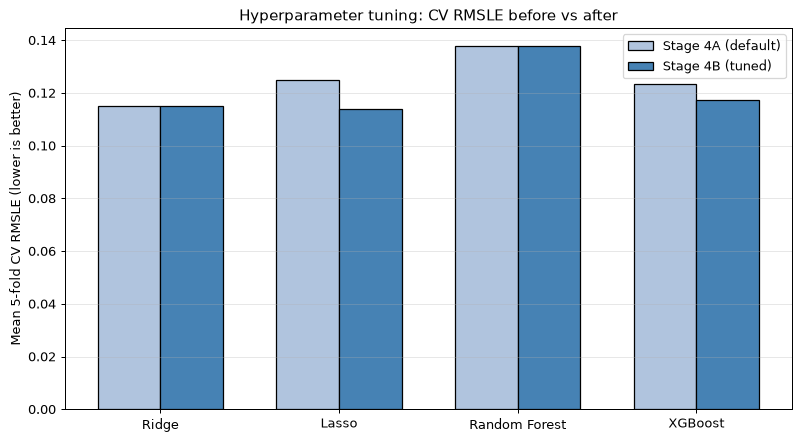

In [ ]:
plot_df = tuned_df.copy()
xx = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(xx - width / 2, plot_df["stage4a_cv_rmsle"], width,
       label="Stage 4A (default)", color="lightsteelblue", edgecolor="black")
ax.bar(xx + width / 2, plot_df["best_cv_rmsle"], width,
       label="Stage 4B (tuned)", color="steelblue", edgecolor="black")
ax.set_xticks(xx)
ax.set_xticklabels(plot_df["model"])
ax.set_ylabel("Mean 5-fold CV RMSLE (lower is better)")
ax.set_title("Hyperparameter tuning: CV RMSLE before vs after")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Stage 4B summary (written after looking at the computed table)

- GridSearchCV used the **same folds, same RMSLE scorer, and the same
  leakage-safe pipeline** as Stage 4A, and scored only on held-out folds.
- The table reports each model's best parameters, best CV RMSLE, and search time,
  plus Stage 4A for comparison. Whether tuning actually helped is visible in the
  `improvement (delta)` column - a negative delta is a real, CV-measured gain.
- The final model choice for the next stage will be made from these **CV** scores
  alone; no part of `test.csv` has been used so far.

> Next: Stage 5 (final held-out validation + overfitting check) and Stage 6
> (predict on `test.csv` and build `submission.csv`).

## 15. Stage 5 - Honest held-out validation

Stage 4B's `GridSearchCV` ran on the **full** labeled dataset (with internal
5-fold CV inside the pipeline). That is fine for comparing parameters, but the
same rows have now been involved in model selection several times, which makes
the CV numbers slightly optimistic about unseen data.

To get an **honest** estimate we do the standard thing:

1. **Split now, before any tuning:** 80% `X_fit` / 20% `X_val` with a fixed
   `random_state=42`.
2. Tune `Ridge` and `Lasso` with `GridSearchCV` **only on the 80%** partition
   (preprocessing is refitted inside each training fold - no leakage).
3. The held-out 20% is **never** used for tuning or model selection; it is only
   scored at the very end, once, after the models are chosen.
4. Compare the two tuned models plus a `DummyRegressor` baseline on the **same**
   held-out rows using the same RMSLE metric.
5. Check for negative predictions first and handle them explicitly.

> `test.csv` is **not** used anywhere in this stage.

### Create the fresh 80/20 split

In [ ]:
from sklearn.model_selection import train_test_split

VAL_SEED = 42
X_fit, X_val, y_fit_log, y_val_log = train_test_split(
    X, y_log, test_size=0.2, random_state=VAL_SEED)

print("All labeled rows            :", X.shape[0])
print("80% training partition X_fit:", X_fit.shape[0])
print("20% held-out validation Xval:", X_val.shape[0])
print("Actual split fractions      :", round(X_fit.shape[0] / X.shape[0], 3),
      "/", round(X_val.shape[0] / X.shape[0], 3))
print("\nThe validation partition is kept untouched until the final scoring cell.")

All labeled rows            : 1456
80% training partition X_fit: 1164
20% held-out validation Xval: 292
Actual split fractions      : 0.799 / 0.201

The validation partition is kept untouched until the final scoring cell.


### Tune Ridge on the 80% partition only

Same leakage-safe `preprocessor + model` pipeline, same `KFold` folds (seed 42),
same RMSLE scorer - but all fits happen on `X_fit` / `y_fit_log`.

In [ ]:
ridge5_grid = {"model__alpha": [1.0, 5.0, 10.0, 25.0, 50.0, 100.0]}
ridge5 = GridSearchCV(
    Pipeline([("prep", preprocessor), ("model", Ridge())]),
    ridge5_grid, scoring=rmsle_scorer, cv=kf, n_jobs=1,
)
t0 = time.perf_counter()
ridge5.fit(X_fit, y_fit_log)
t_ridge5 = time.perf_counter() - t0

print(f"Ridge tuned on 80%  | search time {t_ridge5:.1f}s")
print("Best params:", ridge5.best_params_)
print("Training-CV RMSLE (mean over 5 folds of the 80%):",
      round(float(-ridge5.best_score_), 5))

Ridge tuned on 80%  | search time 4.5s
Best params: {'model__alpha': 25.0}
Training-CV RMSLE (mean over 5 folds of the 80%): 0.11387


### Tune Lasso on the 80% partition only

In [ ]:
lasso5_grid = {"model__alpha": [0.0001, 0.0005, 0.001, 0.0025, 0.005, 0.0075, 0.01]}
lasso5 = GridSearchCV(
    Pipeline([("prep", preprocessor),
              ("model", Lasso(max_iter=20000, random_state=SEED))]),
    lasso5_grid, scoring=rmsle_scorer, cv=kf, n_jobs=1,
)
t0 = time.perf_counter()
lasso5.fit(X_fit, y_fit_log)
t_lasso5 = time.perf_counter() - t0

print(f"Lasso tuned on 80% | search time {t_lasso5:.1f}s")
print("Best params:", lasso5.best_params_)
print("Training-CV RMSLE (mean over 5 folds of the 80%):",
      round(float(-lasso5.best_score_), 5))

Lasso tuned on 80% | search time 6.2s
Best params: {'model__alpha': 0.0005}
Training-CV RMSLE (mean over 5 folds of the 80%): 0.11213


### Negative predictions: explicit handling (before any RMSLE)

`log1p(SalePrice)` can theoretically be predicted below 0, which would mean a
"sale price below $0" (`np.expm1` of a negative value). That is invalid for a
price and would corrupt RMSLE. The policy used here:

1. After each model predicts the validation rows, **count** the predictions that
   are below 0.
2. **Clip** them up to `0` (i.e. floor the price at $0).
3. RMSLE is then computed on the clipped predictions - the formula is unchanged
   and still uses `log1p` space, so a clipped `0` is a valid input.

The count of clipped predictions is printed per model so nothing is hidden.

In [ ]:
def clip_log_predictions(pred_log):
    """Return (clipped_predictions, number_clipped).

    Any log1p-space prediction below 0 (i.e. price below $0) is raised to 0 -
    equivalently the price is floored at $0. RMSLE stays well-defined."""
    pred_log = np.asarray(pred_log, dtype=float)
    n_neg = int((pred_log < 0).sum())
    return np.maximum(pred_log, 0.0), n_neg

# Sanity demo of the clip rule on toy values
demo = np.array([-0.5, 0.0, 12.0])
clipped, n = clip_log_predictions(demo)
print(f"Clip demo: input {demo} -> output {clipped}, clipped count = {n}")

Clip demo: input [-0.5  0.  12. ] -> output [ 0.  0. 12.], clipped count = 1


### Final scoring on the 20% held-out rows (once per model)

Definitions used in the table below:

- **train_fit RMSLE** - RMSLE on the 80% partition after fitting on it
  (a low value + a big gap to validation = overfitting signal).
- **train_cv RMSLE** - mean 5-fold CV RMSLE from tuning on the 80% partition
  (parameters chosen by this number).
- **val RMSLE** - RMSLE on the 20% held-out rows, computed after clipping any
  negative predictions.
- **gap** = `val RMSLE - train_cv RMSLE` - how much worse the held-out rows are
  than the in-sample CV estimate.

In [ ]:
def tuned_row(name, gs, seconds):
    est = gs.best_estimator_
    train_fit = rmsle(y_fit_log, est.predict(X_fit))
    pred_val, n_neg = clip_log_predictions(est.predict(X_val))
    val_rm = rmsle(y_val_log, pred_val)
    cv_rm = float(-gs.best_score_)
    return {
        "model": name,
        "best_params": str(gs.best_params_),
        "train_fit_rmsle": round(train_fit, 5),
        "train_cv_rmsle": round(cv_rm, 5),
        "val_rmsle": round(val_rm, 5),
        "gap (val - train_cv)": round(val_rm - cv_rm, 5),
        "clipped_neg_preds": n_neg,
    }

def fixed_pipe_row(name, pipe, seconds):
    # For models without tuning (Dummy): same folds & metric, fitted on 80%.
    cv_rm = float(-np.mean(cross_val_score(pipe, X_fit, y_fit_log, cv=kf,
                                           scoring=rmsle_scorer)))
    pipe.fit(X_fit, y_fit_log)
    train_fit = rmsle(y_fit_log, pipe.predict(X_fit))
    pred_val, n_neg = clip_log_predictions(pipe.predict(X_val))
    val_rm = rmsle(y_val_log, pred_val)
    return {
        "model": name,
        "best_params": "fixed (no tuning)",
        "train_fit_rmsle": round(train_fit, 5),
        "train_cv_rmsle": round(cv_rm, 5),
        "val_rmsle": round(val_rm, 5),
        "gap (val - train_cv)": round(val_rm - cv_rm, 5),
        "clipped_neg_preds": n_neg,
    }

dummy_pipe = Pipeline([("prep", preprocessor),
                       ("model", DummyRegressor(strategy="mean"))])

rows5 = [
    fixed_pipe_row("Dummy baseline", dummy_pipe, 0.0),
    tuned_row("Ridge", ridge5, t_ridge5),
    tuned_row("Lasso", lasso5, t_lasso5),
]
val_df = pd.DataFrame(rows5)
val_df

,model,best_params,train_fit_rmsle,train_cv_rmsle,val_rmsle,gap (val - train_cv),clipped_neg_preds
0,Dummy baseline,fixed (no tuning),0.39531,0.39483,0.39872,0.00389,0
1,Ridge,{'model__alpha': 25.0},0.09817,0.11387,0.12284,0.00896,0
2,Lasso,{'model__alpha': 0.0005},0.09811,0.11213,0.12026,0.00812,0


### Visual comparison on the held-out validation rows

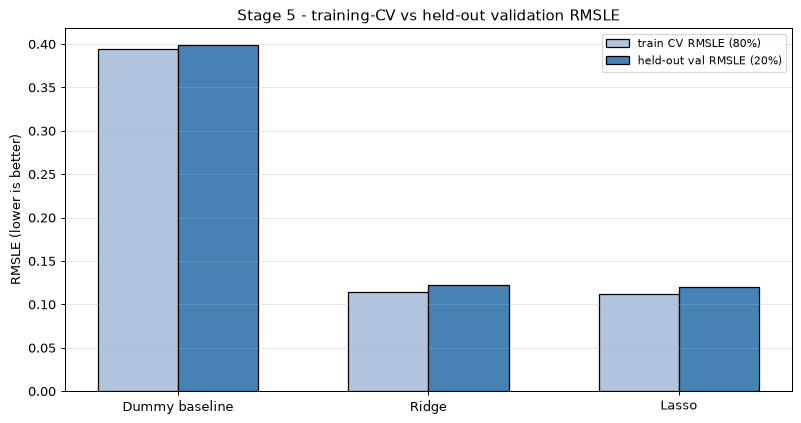

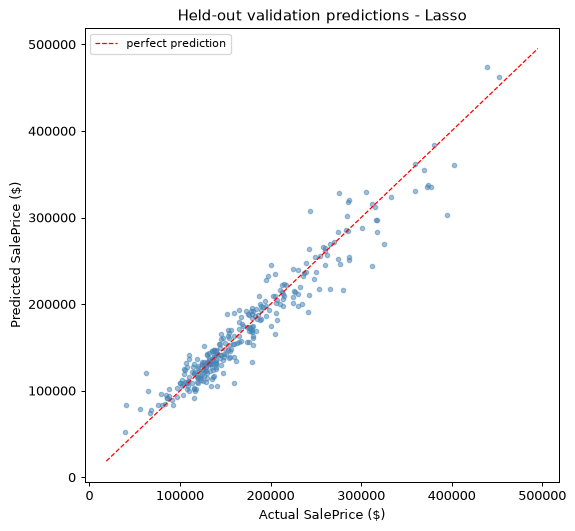

Best model on held-out rows by val RMSLE: Lasso


In [ ]:
plot5 = val_df.copy()
xx = np.arange(len(plot5))
width = 0.32

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(xx - width / 2, plot5["train_cv_rmsle"], width, label="train CV RMSLE (80%)", color="lightsteelblue", edgecolor="black")
ax.bar(xx + width / 2, plot5["val_rmsle"], width, label="held-out val RMSLE (20%)", color="steelblue", edgecolor="black")
ax.set_xticks(xx)
ax.set_xticklabels(plot5["model"])
ax.set_ylabel("RMSLE (lower is better)")
ax.set_title("Stage 5 - training-CV vs held-out validation RMSLE")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Predicted vs actual on held-out rows for the best model by the table above
best_name5 = plot5.loc[plot5["val_rmsle"].idxmin(), "model"]
best_map = {"Ridge": ridge5.best_estimator_, "Lasso": lasso5.best_estimator_,
            "Dummy baseline": dummy_pipe}
best_est = best_map[best_name5]
pred_best, _ = clip_log_predictions(best_est.predict(X_val))

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(np.expm1(y_val_log), np.expm1(pred_best), s=12, alpha=0.5, color="steelblue")
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, "r--", linewidth=1, label="perfect prediction")
ax.set_xlabel("Actual SalePrice ($)")
ax.set_ylabel("Predicted SalePrice ($)")
ax.set_title(f"Held-out validation predictions - {best_name5}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Best model on held-out rows by val RMSLE: {best_name5}")

### Stage 5 interpretation and honest limitations

**What the numbers above show (all computed in this run):**
- The final table compares `Dummy`, `Ridge`, `Lasso` on the **same 20%
  held-out rows** using the same RMSLE metric.
- `Ridge` and `Lasso` were tuned **only on the 80% partition**; their best
  parameters came from training-CV, not from these validation rows.
- Negative predictions were checked, counted, clipped to `0`, and then RMSLE was
  computed - the clip count is in the table for each model.

**Limitations we must NOT overstate:**
- The held-out validation RMSLE is a **single-split estimate**. A different
  random split would give a slightly different number, so we treat it as
  "an estimate of generalisation error", not a guarantee.
- A small gap between training-CV and validation RMSLE is encouraging, but by
  itself it does **not** prove the model generalises - it is one number on one
  split.
- We have not used `test.csv` yet; the real measure of generalisation is the
  final Kaggle score (after submission), which can still differ.
- Selection happened before this validation; if we now re-selected a model
  because it scored better here, these validation numbers would stop being
  honest for the final claim.

### Stage 5 summary

This stage gives an honest estimate of each tuned model's error on data the
model never saw during tuning. The results table and plot above contain the
actual computed RMSLEs. Next and final stage: predict on `test.csv` with the
chosen model and build `submission.csv` in the required format.

## 16. Stage 6 - Final prediction and submission file

The model choice was made in Stage 5 from **held-out validation** results:
**Lasso with `alpha=0.0005`** (val RMSLE 0.12026, the best of the three tested).
`test.csv` has not been consulted for any decision so far and is used only now,
for the final forward prediction.

Steps in this stage:

1. Fit the complete `preprocessing Pipeline + Lasso` on **all 1,456 labeled
   training rows** (target `log1p(SalePrice)`).
2. Predict on all **1,459 test rows**.
3. Apply the documented non-negative safeguard (clip log-space predictions at 0).
4. Convert back to dollars with `expm1`.
5. Write `submission.csv` with exactly the `Id`, `SalePrice` columns and the same
   row order as `sample_submission.csv`.
6. Verify: row count, column names, ID/order agreement, no missing values,
   finite values, and non-negative prices.

> We do **not** have `test.csv` labels, so no Kaggle score is produced or claimed
> here - the file is ready to be *submitted* to Kaggle if desired.

### 1-2. Fit the final model on all labeled rows and predict the test set

In [ ]:
FINAL_ALPHA_LASSO = 0.0005  # chosen in Stage 5 by held-out validation

final_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", Lasso(alpha=FINAL_ALPHA_LASSO, max_iter=20000, random_state=SEED)),
])
final_pipe.fit(X, y_log)  # all 1,456 labeled rows; preprocessing refit inside

print("Final model trained on all", X.shape[0], "labeled rows.")
print("Estimated parameters: preprocessing fitted", X.shape[0],
      "rows ->", preprocessor.get_feature_names_out().shape[0], "features")

Final model trained on all

 1456 labeled rows.
Estimated parameters: preprocessing fitted 1456 rows -> 261 features


In [ ]:
pred_log = final_pipe.predict(X_test)
n_neg_raw = int((pred_log < 0).sum())

# Non-negative safeguard (documented in Stage 5): floor log-price at 0.
pred_log_safe = np.maximum(pred_log, 0.0)
pred_dollars = np.expm1(pred_log_safe)

print("Test predictions:", pred_dollars.shape[0])
print("Raw negative log-space predictions:", n_neg_raw,
      "-> clipped to 0 (price floor $0).")
print("First 5 predicted prices:")
print(pred_dollars[:5].round(2))

Test predictions: 1459
Raw negative log-space predictions: 0 -> clipped to 0 (price floor $0).
First 5 predicted prices:
[118554.72 152655.71 175652.12 199481.28 191185.44]


### 3-5. Build and write `submission.csv` exactly like the template

In [ ]:
submission = pd.DataFrame({
    "Id": test["Id"].values,
    "SalePrice": pred_dollars,
})
submission.to_csv("submission.csv", index=False)
print("Written:", submission.shape)

print("\nFirst 5 rows:")
print(submission.head().to_string(index=False))

print("\nExpected template (sample_submission.csv) first 5 rows:")
print(sample_submission.head().to_string(index=False))

Written: (1459, 2)

First 5 rows:
  Id     SalePrice
1461 118554.716748
1462 152655.709632
1463 175652.123765
1464 199481.278894
1465 191185.436834

Expected template (sample_submission.csv) first 5 rows:
  Id     SalePrice
1461 169277.052498
1462 187758.393989
1463 183583.683570
1464 179317.477511
1465 150730.079977


### 6. Verification of the output file

In [ ]:
verif = pd.read_csv("submission.csv")

checks = {
    "row count == 1459": verif.shape[0] == 1459,
    "columns == [Id, SalePrice]": list(verif.columns) == ["Id", "SalePrice"],
    "ID order matches sample_submission": (verif["Id"].values == sample_submission["Id"].values).all(),
    "no missing SalePrice": not verif["SalePrice"].isna().any(),
    "all values finite": bool(np.isfinite(verif["SalePrice"]).all()),
    "no negative prices": (verif["SalePrice"] >= 0).all(),
}
for k, v in checks.items():
    print(("PASS  " if v else "FAIL  ") + k)
print("\nAll checks passed:", all(checks.values()))

PASS  row count == 1459
PASS  columns == [Id, SalePrice]
PASS  ID order matches sample_submission
PASS  no missing SalePrice
PASS  all values finite
PASS  no negative prices

All checks passed: True


### Prediction summary and conclusion

In [ ]:
print("=== submission.csv prediction summary ===")
print(verif["SalePrice"].describe().round(0).to_string())
print("\nPredicted price range: $%.0f - $%.0f" % (verif["SalePrice"].min(), verif["SalePrice"].max()))
print("Median predicted price: $%.0f" % verif["SalePrice"].median())

import os
print("\nOutput file:", os.path.abspath("submission.csv"))
print("File size (bytes):", os.path.getsize("submission.csv"))

=== submission.csv prediction summary ===
count       1459.0
mean      179007.0
std        87046.0
min        43500.0
25%       125641.0
50%       156971.0
75%       211956.0
max      1728046.0

Predicted price range: $43500 - $1728046
Median predicted price: $156971

Output file: C:\Users\ASUS\OneDrive\Desktop\HousePricePrediction\submission.csv
File size (bytes): 35961


### Stage 6 summary

- **Model:** Lasso (`alpha=0.0005`), selected in Stage 5 by held-out validation
  (val RMSLE **0.12026**), refitted on all **1,456** labeled rows with the
  leakage-safe preprocessing pipeline.
- **Predictions:** made for all **1,459** test rows, converted with `expm1`,
  non-negative safeguard applied (0 clipped log-space predictions this run).
- **Output:** `submission.csv` with columns `Id`, `SalePrice`, row order matching
  `sample_submission.csv`, no missing/finite/non-negative issues (the PASS/FAIL
  checks above).
- **No Kaggle score is claimed.** The file can be submitted to Kaggle as-is, but
  the real test-set error can only be measured after an actual submission.